In [ ]:
import os
os.listdir("/content")
#doing the usual here!!!


['.config',
 'River_50m_sorted.zip',
 'Orco_river.zip',
 'River_20m_sorted.zip',
 'Orco',
 'sample_data']

In [ ]:
import zipfile

zip_path = "/content/Orco_river.zip"
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("/content/Orco")

print("Done!") #extracting as always

Done!


okie, looking ! a mixture of left and right here! ok tbh long numbers look like dates, recent  data!! wondering what the 50/20m is? data every 50/20m. omg there's a lot of data, hm not sure what to expect so will open one up as always! cus it's actual project. im gonna do systematically? in the order in the zip ? hm no will do by date and resave seems easier?

ah wait will have to check the avg file after, for loop etc will need to skip that one!

oh two different directories?

In [ ]:
import os
river20_out = "/content/Orco/River_20m_sorted"
river50_out = "/content/Orco/River_50m_sorted"

os.makedirs(river20_out, exist_ok=True)
os.makedirs(river50_out, exist_ok=True)

In [ ]:
river50_files = sorted(
    [f for f in os.listdir(river_source)
     if f.startswith("river_points_50m")],
    key=lambda x: x.split("_")[-1].replace(".geojson", ""))

for f in river50_files:
    shutil.copy(os.path.join(river_source, f), os.path.join(river50_out, f))

print(f"Copied {len(river50_files)} 50 m river files.")

NameError: name 'river_source' is not defined

In [ ]:
for f in sorted(
    os.listdir(river20_out),
    key=lambda x: x.split("_")[-1].replace(".geojson", "")):
    print(f)

In [ ]:
for f in sorted(
    os.listdir(river50_out),
    key=lambda x: x.split("_")[-1].replace(".geojson", "")):
    print(f)

In [ ]:
import shutil

shutil.make_archive("/content/River_20m_sorted", "zip", river20_out)
shutil.make_archive("/content/River_50m_sorted", "zip", river50_out)
print("Done!")

Done!


In [ ]:
import geopandas as gpd #did research here, have used pandas before so pretty familiar !!

gdf = gpd.read_file("/content/Orco/River_20m_sorted/river_points_20m_236_075R_20250506.geojson")

DataSourceError: /content/Orco/River_20m_sorted/river_points_20m_236_075R_20250506.geojson: No such file or directory

er print column headers!!

In [ ]:
print(gdf.columns)

Index(['id', 'Name', 'description', 'timestamp', 'begin', 'end',
       'altitudeMode', 'tessellate', 'extrude', 'visibility', 'drawOrder',
       'icon', 'fid', 'cngmeters', 'river_id', 'height', 'avg_geoloc_qual',
       'geoid', 'dist_along_ctrline', 'geometry'],
      dtype='object')


ok very different to previous data. more processed potentially?

kind of seeing what this gives

In [ ]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 10731 entries, 0 to 10730
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   id                  0 non-null      object  
 1   Name                0 non-null      object  
 2   description         0 non-null      object  
 3   timestamp           0 non-null      object  
 4   begin               0 non-null      object  
 5   end                 0 non-null      object  
 6   altitudeMode        0 non-null      object  
 7   tessellate          10731 non-null  int32   
 8   extrude             10731 non-null  int32   
 9   visibility          10731 non-null  int32   
 10  drawOrder           0 non-null      object  
 11  icon                0 non-null      object  
 12  fid                 10731 non-null  float64 
 13  cngmeters           10731 non-null  float64 
 14  river_id            10731 non-null  int32   
 15  height              9876 non

ok less data points that the other file types?

geometry? of the river ? lon lat i guess we'll plot and see !

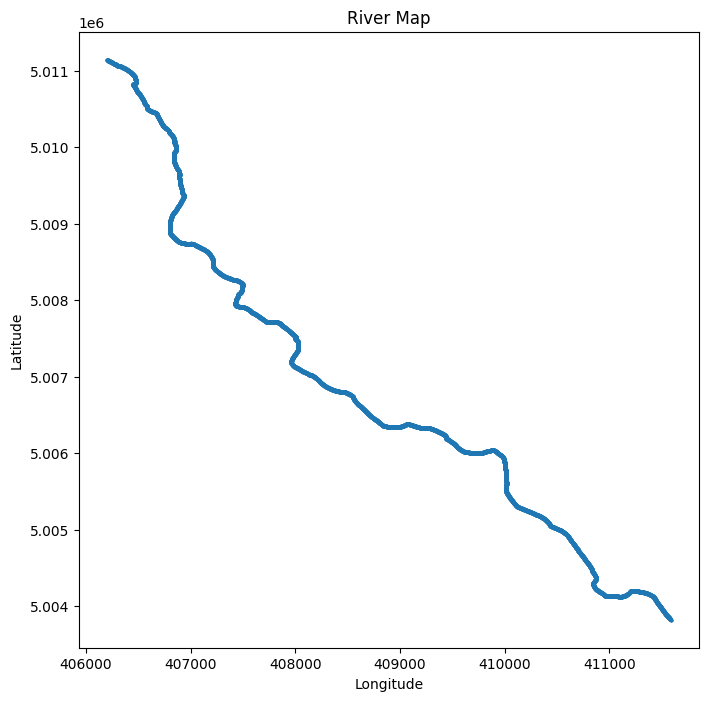

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,8))

plt.scatter(
    gdf.geometry.x, #use lat and lon, think units !
    gdf.geometry.y,
    s=3)

plt.xlabel("Longitude") #so this is using lat and lon!!! just kind of trying to map it route here.
plt.ylabel("Latitude")
plt.title("River Map")
plt.show()

Pretty big section of river !!

In [ ]:
print(gdf.describe())

       tessellate  extrude  visibility      fid     cngmeters      river_id  \
count     10731.0  10731.0     10731.0  10731.0  10731.000000  10731.000000   
mean         -1.0      0.0        -1.0      0.0   5365.000000   5365.000000   
std           0.0      0.0         0.0      0.0   3097.917204   3097.917204   
min          -1.0      0.0        -1.0      0.0      0.000000      0.000000   
25%          -1.0      0.0        -1.0      0.0   2682.500000   2682.500000   
50%          -1.0      0.0        -1.0      0.0   5365.000000   5365.000000   
75%          -1.0      0.0        -1.0      0.0   8047.500000   8047.500000   
max          -1.0      0.0        -1.0      0.0  10730.000000  10730.000000   

            height  avg_geoloc_qual        geoid  dist_along_ctrline  
count  9876.000000           9876.0  9876.000000         9876.000000  
mean    192.622648              0.0    48.443705         5532.199399  
std      10.239823              0.0     0.379113         3132.630297  
min 

Data? distance along centreline? i believe?

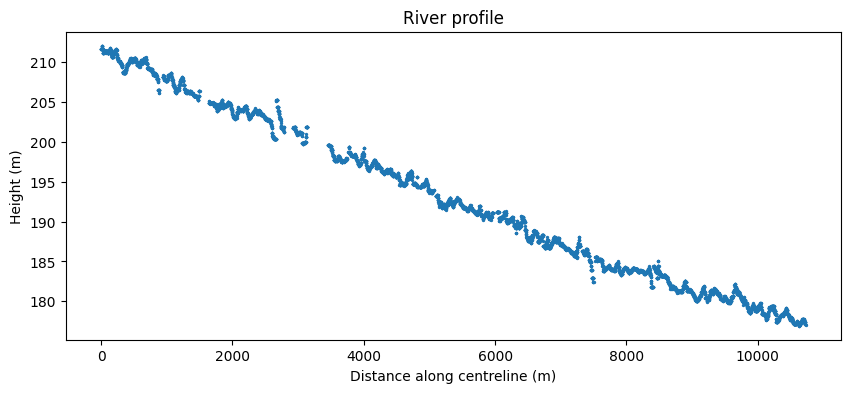

In [ ]:
plt.figure(figsize=(10,4))
plt.scatter(
    gdf["dist_along_ctrline"],
    gdf["height"], #height = the surface elevation !! above reference? geoid?
    s=3)

plt.xlabel("Distance along centreline (m)") #distance
plt.ylabel("Height (m)")
plt.title("River Heights")
plt.show()

Ok gaps in the data? so theres kind of an obvious trend here !! its flowing downhill (as expected lol), by decreasing height!!

so also its obviously not uniform !! how is steepness changing is kind of my main one! some of it is prob noise - how can i find out ?

In [ ]:
from scipy.stats import linregress #using classic linregress for lobf
x = gdf["dist_along_ctrline"]
y = gdf["height"]
fit = linregress(x,y)
print(f"Slope = {fit.slope:} ")
print(f"Intercept = {fit.intercept:} m")

Slope = nan 
Intercept = nan m


right well that didn't work at all, errrrrrrrr need to see what the hell is going on ? maye cus some vals are missing ?

er a million Nans. Have these been removed by processing ? i assume this is Level 2 data.

In [ ]:
print("NaNs in distance:", gdf["dist_along_ctrline"].isna().sum())
print("NaNs in height:", gdf["height"].isna().sum()) #im literally just trying to figure out how much of this data is Nan - there's quite a lot!!!

NaNs in distance: 855
NaNs in height: 855


i kind of just want to get an actual visual on this

In [ ]:
nan_height = gdf[gdf["height"].isna()]
print(nan_height)

        id  Name description timestamp begin   end altitudeMode  tessellate  \
885   None  None        None      None  None  None         None          -1   
886   None  None        None      None  None  None         None          -1   
887   None  None        None      None  None  None         None          -1   
888   None  None        None      None  None  None         None          -1   
889   None  None        None      None  None  None         None          -1   
...    ...   ...         ...       ...   ...   ...          ...         ...   
8409  None  None        None      None  None  None         None          -1   
8410  None  None        None      None  None  None         None          -1   
8411  None  None        None      None  None  None         None          -1   
8412  None  None        None      None  None  None         None          -1   
8413  None  None        None      None  None  None         None          -1   

      extrude  visibility drawOrder  icon  fid  cng

removing Nans

In [ ]:
valid = gdf["height"].notna() & gdf["dist_along_ctrline"].notna() #remiving the nans had to search tbh but was pretty intuitive!
x = gdf.loc[valid, "dist_along_ctrline"]
y = gdf.loc[valid, "height"]

fit = linregress(x, y)

print(f"Slope = {fit.slope:.6f}") #just played around w precision here ! think these units work best
print(f"Intercept = {fit.intercept:.2f} m") #will prob convert to km actually lol


Slope = -0.003255
Intercept = 210.63 m


Intercept is height at distance=0m, so i assume its the starting height?? at the start of the stream? and the slope is obv how quickly that height is changing- it seems pretty shallow! hmmmmmmm idk how i feel about that? seems too low would need to compare to other data? naybe just high precision? negatuve is making me feel reassured

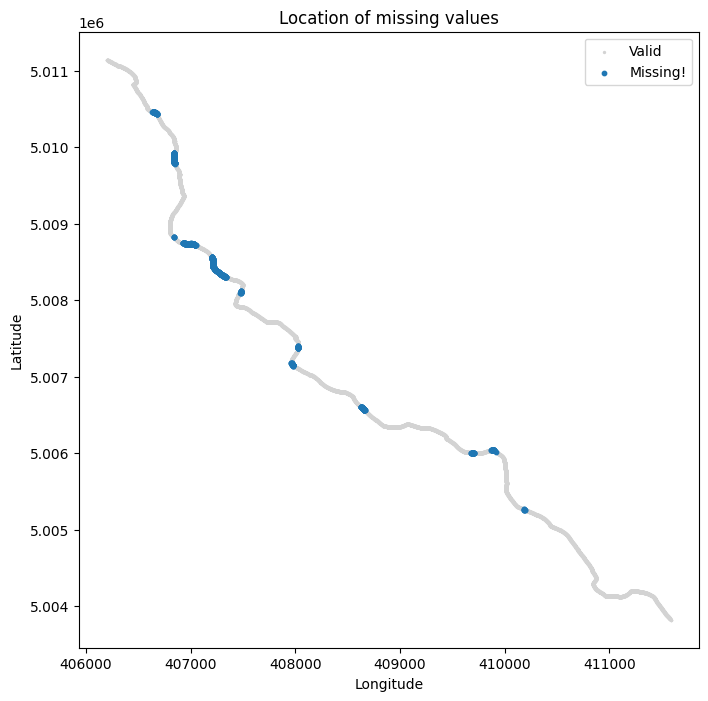

In [ ]:
plt.figure(figsize=(8,8))

plt.scatter(
    gdf.geometry.x,
    gdf.geometry.y,
    s=2,
    color="lightgrey",
    label="Valid") #changed to light grey otherise u could genuinely see nothing

plt.scatter(
    nan_height.geometry.x,
    nan_height.geometry.y,
    s=10,
    label="Missing!")

plt.legend()
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Location of missing values")
plt.show()

This is where the missing data is !!!! I wonder if there's any correlation with where they are and why there ? I assume its to do with surface roughness.

Try with other data and compare the lat/lon ? could j be low coherence etc or the drone !!

Going to plot the regression line cus tbh there's a fair amount of noise, would be interesting to see if its random and cancels with averaging?

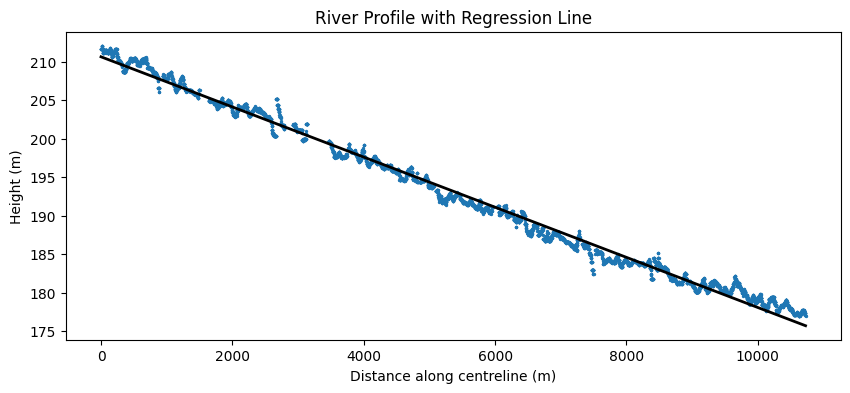

In [ ]:
plt.figure(figsize=(10,4))
plt.scatter(x, y, s=2)

plt.plot(
    x,
    fit.intercept + fit.slope*x, #so this is just me plotting previous plot, and then fitting a regression line over!!
    color="black",
    linewidth=2) #just want to kind of investigate the data!! the trend is obvious but some numbers would be nice.

plt.xlabel("Distance along centreline (m)")
plt.ylabel("Height (m)")
plt.title("River Profile with Regression Line")
plt.show()

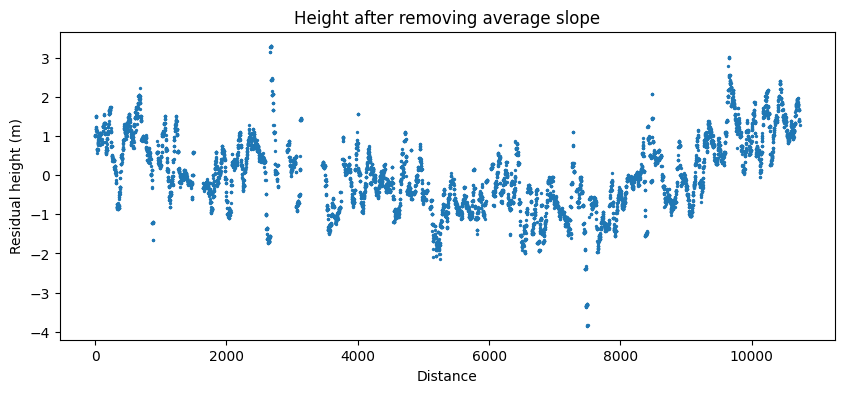

In [ ]:
residual = y - (fit.intercept + fit.slope*x) #here im just finding the diff between the trend and our actual!
#this is to see where the most noise is!
plt.figure(figsize=(10,4))
plt.scatter(x, residual, s=2)
plt.xlabel("Distance")
plt.ylabel("Residual height (m)")
plt.title("Height after removing average slope")

plt.show()

It kind of trends around zero (good! it follows our downstream linear trend vaguely) BUT lots of fluc and noise! At the start seems higher than expected, then moves below then higher again -  cus its longer stretches i think more liekly the small fluc are noise encompassed in an overall subtle kind of envelope which represents the actual changes in height as we move downstream? - basically im saying our gradient in height change is changing as we move down from the looks of things so would be interesting to maybe observe individually if we roughly/observationally split into thirds and see?

I think next steps !! would be to investigate HOW the height gradient changes as we move downstream soooo already am kind of thinking how will the noise affect? will i have to average ? is that even accurate? tbf were looking for general trends but still!

errrrrr moving on for now! more data inespction tbh

theres a lot here i dont massively understand! so investigate!

look into

In [ ]:
gdf["timestamp"].head()

,timestamp
0,None
1,None
2,None
3,None
4,None


am i being stupid? er nothing in here ? tbf i suppose all time info is in header - not tlly end of the world!

In [ ]:
gdf["timestamp"].isna().sum() #okie is all of them - will just ignore

np.int64(10731)

In [ ]:
gdf["river_id"].unique()

array([    0,     1,     2, ..., 10728, 10729, 10730], dtype=int32)

wth is river id ???????? seems like point identifiers given the point numbers ?

In [ ]:
gdf["dist_along_ctrline"].head(20)
gdf["dist_along_ctrline"].tail(20)

,dist_along_ctrline
10711,10707.607686
10712,10708.607489
10713,10709.607489
10714,10710.607489
10715,10711.607489
10716,10712.607489
10717,10713.607489
10718,10714.607489
10719,10715.607489
10720,10716.607489


wait are rhe pixc files less processed? genuinely just a basic assumption cus theres less data in the river points ones!

In [ ]:
import geopandas as gpd

pixc = gpd.read_file("/content/Orco/PIXC_sorted/PIXC_236_075R_20250415.geojson")

In [ ]:
print(pixc.columns)

Index(['height', 'classification', 'classification_qual', 'bright_land_flag',
       'geolocation_qual', 'interferogram_qual', 'sig0', 'sig0_qual',
       'coherent_power', 'latitude', 'longitude', 'pole_tide',
       'height_cor_xover', 'solid_earth_tide', 'pixel_area', 'load_tide_fes',
       'load_tide_got', 'iono_cor_gim_ka', 'geoid', 'geometry'],
      dtype='object')


pixc - subset for our area from swot

future work: focus on v dist across river width, also if angle of river changes ? also areas of river perp to ground track has more doppler shift effect, aligned ground track see less

next plots! scatter w residuals along river !! and export to kml, save each point individually.

height change from bow in centre gives phase channge

Plan for today! investigate some pixc data and try and figure out how to plot velocity! then move onto angle, so i suppose that will just be investigating where and maybe highlighting certain sections

then try the kml stuff again! hopefully wifi better here?

cross track distance ~ distance across teh river ! but obviously will need to investigate where the changes are

In [ ]:
!pip install rarfile
import rarfile

rf = rarfile.RarFile("/content/sat_paths.rar")
rf.extractall("/content/sat_paths")

In [ ]:
#wth is in here!
import os

for root, dirs, files in os.walk("/content/sat_paths"):
    print(root)
    for f in files:
        print("   ", f)

/content/sat_paths
/content/sat_paths/sat_paths
    SWOT_L2_HR_PIXC_032_542_075L_20250517T085627_20250517T085638_PID0_01.csv
    SWOT_L2_HR_PIXC_041_307_234L_20251112T183839_20251112T183850_PID0_02.csv
    SWOT_L2_HR_PIXC_032_029_234R_20250429T013040_20250429T013051_PGD0_01.csv
    SWOT_L2_HR_PIXC_039_236_074R_20250929T114902_20250929T114913_PID0_01.csv
    SWOT_L2_HR_PIXC_032_236_074R_20250506T103328_20250506T103339_PGD0_01.csv
    SWOT_L2_HR_PIXC_036_236_075R_20250728T213400_20250728T213411_PID0_01.csv
    SWOT_L2_HR_PIXC_041_307_234L_20251112T183839_20251112T183850_PID0_01.csv
    SWOT_L2_HR_PIXC_031_542_075L_20250426T121123_20250426T121134_PGD0_01.csv
    SWOT_L2_HR_PIXC_039_542_075L_20251010T101200_20251010T101211_PID0_01.csv
    SWOT_L2_HR_PIXC_034_236_074R_20250617T040338_20250617T040349_PID0_01.csv
    SWOT_L2_HR_PIXC_031_236_075R_20250415T134835_20250415T134846_PGD0_02.csv
    SWOT_L2_HR_PIXC_038_307_234L_20250911T042325_20250911T042337_PID0_01.csv
    SWOT_L2_HR_PIXC_033_307_

okieeee obv level 2!!

In [ ]:
import os

for root, dirs, files in os.walk("/content/sat_paths"):
    print(root)
    print("Number of files:", len(files))
    if len(files) > 0:
        print(files[:5])   # first 5 files
        print()

/content/sat_paths
Number of files: 0
/content/sat_paths/sat_paths
Number of files: 70
['SWOT_L2_HR_PIXC_032_542_075L_20250517T085627_20250517T085638_PID0_01.csv', 'SWOT_L2_HR_PIXC_041_307_234L_20251112T183839_20251112T183850_PID0_02.csv', 'SWOT_L2_HR_PIXC_032_029_234R_20250429T013040_20250429T013051_PGD0_01.csv', 'SWOT_L2_HR_PIXC_039_236_074R_20250929T114902_20250929T114913_PID0_01.csv', 'SWOT_L2_HR_PIXC_032_236_074R_20250506T103328_20250506T103339_PGD0_01.csv']



In [ ]:
import pandas as pd

csv = pd.read_csv(
    "/content/sat_paths/sat_paths/SWOT_L2_HR_PIXC_032_236_074R_20250506T103328_20250506T103339_PID0_02.csv"
)

csv.head()

,name,lat_sat,lon_sat
0,SWOT_L2_HR_PIXC_032_236_074R_20250506T103328_2...,46.037560,8.370060
1,SWOT_L2_HR_PIXC_032_236_074R_20250506T103328_2...,46.037533,8.370071
2,SWOT_L2_HR_PIXC_032_236_074R_20250506T103328_2...,46.037506,8.370081
3,SWOT_L2_HR_PIXC_032_236_074R_20250506T103328_2...,46.037479,8.370092
4,SWOT_L2_HR_PIXC_032_236_074R_20250506T103328_2...,46.037452,8.370102


In [ ]:
#seeing wth is in here againnn
print("Rows:", len(csv))
print("Columns:", len(csv.columns))

Rows: 23562
Columns: 3


In [ ]:
print(csv.columns)

Index(['name', 'lat_sat', 'lon_sat'], dtype='object')


In [ ]:
csv.head()

,name,lat_sat,lon_sat
0,SWOT_L2_HR_PIXC_032_236_074R_20250506T103328_2...,46.037560,8.370060
1,SWOT_L2_HR_PIXC_032_236_074R_20250506T103328_2...,46.037533,8.370071
2,SWOT_L2_HR_PIXC_032_236_074R_20250506T103328_2...,46.037506,8.370081
3,SWOT_L2_HR_PIXC_032_236_074R_20250506T103328_2...,46.037479,8.370092
4,SWOT_L2_HR_PIXC_032_236_074R_20250506T103328_2...,46.037452,8.370102


satellite tracks ok just name lon and lat

so im obv j going to plot the satellite track!

In [ ]:
plt.figure(figsize=(6,8))

plt.plot(
    csv["lon_sat"],
    csv["lat_sat"],
    linewidth=1
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("SWOT satellite ground track")

plt.axis("equal")
plt.show()

NameError: name 'plt' is not defined